# Section C grid experiments: one TAVIE fit, all gap quantities

This notebook contains the Student's-$t$ grid experiments and their
relevant plots (Figures 5--8 of the supplementary materials).

Each $(n,p,\mathrm{rep})$ job fits TAVIE **once** and reuses that fitted
model to collect:

1. the post-convergence ELBO approximation gap
   $\mathsf{L}_{\mathrm{true}}(\xi^\star)-\mathsf{L}(\xi^\star)$;
2. the post-convergence variational gap
   $\log p_\alpha(y\mid\mathbf X)-\mathsf{L}(\xi^\star)$; and
3. $\mathsf{L}(\xi^\star)-\log p_\alpha(y\mid\mathbf X,\theta_0)$.

All raw scalar values, diagnostic traces, summaries, configuration, and
fixed true coefficients are saved together in
`results_gaps/student_t_grid_all_quantities.pkl`. A later section reloads
that file before making any plots.

## Dimension convention

In this notebook, $p$ is always the **total number of regression
coefficients, including the intercept**. Thus `X.shape[1] == p - 1`, the
prior mean has length `p`, and every plotted expression such as
$(p/2)\log n$ uses this total dimension directly. No plot adds one to `p`.

The random-number seeds continue to use `n_predictors = p - 1` only to
reproduce the datasets generated by the original notebook.

In [1]:
# Required imports and experiment configuration
import os
import pickle
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import gammaln, logsumexp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from TAVIE_true_elbo import TAVIE_loc_scale
from TAVIE_true_elbo.compare_true_elbo import compare_type_I


OUTPUT_DIR = Path("results_gaps")
PLOTS_DIR = OUTPUT_DIR / "plots"
ALL_RESULTS_PATH = OUTPUT_DIR / "student_t_grid_all_quantities.pkl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed_global": 123,
    "tau2_true": 3.0,
    "df": 5,
    "alpha": 1.0,
    "a0": 0.025,
    "b0": 0.025,
    "n_values": [1000, 4000, 8000, 12000],
    # p includes the intercept in every value below.
    "p_values": [11, 21, 41, 81, 161],
    "num_reps": 10,
    "maxiter": 1000,
    "tol": 1e-9,
    "n_mc_true_elbo": 1000,
    "n_is_logml": 10_000,
    "is_batch_size": 128,
    "tail_fraction": 0.10,
    "tail_summary": "mean_tail",
    "checkpoint_every": 5,
}

# If True, a compatible partial bundle is resumed. Set False to replace it.
RESUME = True

print("p includes intercept:", CONFIG["p_values"])
print("Consolidated output:", ALL_RESULTS_PATH)

p includes intercept: [11, 21, 41, 81, 161]
Consolidated output: results_gaps/student_t_grid_all_quantities.pkl


## Shared numerical helpers

The importance sampler below follows the Normal--Gamma parameterization
used by TAVIE:
$q(\tau^2)=\mathrm{Gamma}(a/2,b/2)$ (shape/rate) and
$q(\beta\mid\tau^2)=\mathcal N(m,V/\tau^2)$. Likelihood evaluation is
batched to avoid constructing an `n × n_is` array for the largest grid
points.

In [2]:
def summarize_tail(values, tail_fraction=0.10, method="mean_tail"):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        raise ValueError("Cannot summarize an empty trace.")

    start = max(0, int(np.floor((1.0 - tail_fraction) * values.size)))
    tail = values[start:]

    if method == "mean_tail":
        return float(np.mean(tail))
    if method == "median_tail":
        return float(np.median(tail))
    if method == "last":
        return float(values[-1])
    raise ValueError(f"Unknown tail summary: {method}")


def generate_student_data(n, p, beta_true, tau2_true, df, seed):
    """Generate data when p is the coefficient count including intercept."""
    if p < 2:
        raise ValueError("p must include an intercept and at least one predictor.")
    if len(beta_true) != p:
        raise ValueError(f"Expected beta_true of length {p}, got {len(beta_true)}.")

    n_predictors = p - 1
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, n_predictors))
    error = rng.standard_t(df=df, size=n) / np.sqrt(tau2_true)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


def log_gamma_density_rate(x, shape, rate):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, -np.inf, dtype=float)
    positive = x > 0
    xp = x[positive]
    out[positive] = (
        shape * np.log(rate)
        - gammaln(shape)
        + (shape - 1.0) * np.log(xp)
        - rate * xp
    )
    return out


def sample_normal_gamma_tavie(m, V, a, b, n_samples, rng):
    """Sample q(beta,tau2) with tau2 ~ Gamma(a/2, rate=b/2)."""
    tau2 = rng.gamma(shape=a / 2.0, scale=2.0 / b, size=n_samples)
    chol = np.linalg.cholesky(V)
    z = rng.normal(size=(n_samples, len(m)))
    beta = np.asarray(m)[None, :] + (z @ chol.T) / np.sqrt(tau2)[:, None]
    return beta, tau2


def log_normal_gamma_tavie(beta, tau2, m, V, a, b):
    """Log density for TAVIE's Normal--Gamma parameterization."""
    beta = np.asarray(beta, dtype=float)
    tau2 = np.asarray(tau2, dtype=float)
    m = np.asarray(m, dtype=float)
    V = np.asarray(V, dtype=float)
    dimension = m.size

    sign, logdet_V = np.linalg.slogdet(V)
    if sign <= 0:
        raise ValueError("V must be positive definite.")

    diff = beta - m[None, :]
    solved = np.linalg.solve(V, diff.T).T
    quadratic = tau2 * np.einsum("ij,ij->i", diff, solved)
    log_beta_given_tau2 = -0.5 * (
        dimension * np.log(2.0 * np.pi)
        + logdet_V
        - dimension * np.log(tau2)
        + quadratic
    )
    log_tau2 = log_gamma_density_rate(tau2, a / 2.0, b / 2.0)
    return log_beta_given_tau2 + log_tau2


def fractional_student_loglik_samples(
    y, X_design, beta, tau2, nu, alpha=1.0
):
    """Return alpha * log p(y | beta,tau2) for a batch of draws."""
    means = X_design @ beta.T
    residuals = y[:, None] - means
    constant = (
        gammaln((nu + 1.0) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * np.log(nu * np.pi)
    )
    contributions = (
        constant
        + 0.5 * np.log(tau2)[None, :]
        - 0.5
        * (nu + 1.0)
        * np.log1p(tau2[None, :] * residuals**2 / nu)
    )
    return alpha * np.sum(contributions, axis=0)


def estimate_log_marginal_alpha_student(
    model, prior_params, nu, alpha, n_is, batch_size, seed
):
    """Importance-sampling estimate using the fitted TAVIE q as proposal."""
    m0, V0, a0, b0 = prior_params
    estimates = model.get_variational_estimates()
    m = np.asarray(estimates["m_xi"], dtype=float)
    V = np.asarray(estimates["V_xi"], dtype=float)
    a = float(estimates["a_xi"])
    b = float(estimates["b_xi"])

    X_design = np.asarray(model.design_matrix, dtype=float)
    y = np.asarray(model.y, dtype=float)
    if X_design.shape[1] != m.size:
        raise ValueError("Design and variational dimensions do not agree.")

    rng = np.random.default_rng(seed)
    log_weight_batches = []
    generated = 0

    while generated < n_is:
        batch_n = min(batch_size, n_is - generated)
        beta, tau2 = sample_normal_gamma_tavie(
            m=m, V=V, a=a, b=b, n_samples=batch_n, rng=rng
        )
        loglik = fractional_student_loglik_samples(
            y=y,
            X_design=X_design,
            beta=beta,
            tau2=tau2,
            nu=nu,
            alpha=alpha,
        )
        logprior = log_normal_gamma_tavie(
            beta=beta, tau2=tau2, m=m0, V=V0, a=a0, b=b0
        )
        logq = log_normal_gamma_tavie(
            beta=beta, tau2=tau2, m=m, V=V, a=a, b=b
        )
        log_weight_batches.append(loglik + logprior - logq)
        generated += batch_n

    log_weights = np.concatenate(log_weight_batches)
    logml_hat = float(logsumexp(log_weights) - np.log(log_weights.size))

    normalized_weights = np.exp(log_weights - logsumexp(log_weights))
    importance_ess = float(1.0 / np.sum(normalized_weights**2))
    return logml_hat, importance_ess


def fractional_student_loglik_at_theta0(
    y, X, beta_true, tau2_true, nu, alpha=1.0
):
    mean = beta_true[0] + X @ beta_true[1:]
    residual = y - mean
    constant = (
        gammaln((nu + 1.0) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * np.log(nu * np.pi)
    )
    values = (
        constant
        + 0.5 * np.log(tau2_true)
        - 0.5
        * (nu + 1.0)
        * np.log1p(tau2_true * residual**2 / nu)
    )
    return float(alpha * np.sum(values))


def summarize_metric(raw_results, metric):
    summary = (
        raw_results.groupby(["n", "p"], as_index=False)
        .agg(
            gap_mean=(metric, "mean"),
            gap_median=(metric, "median"),
            gap_std=(metric, "std"),
            gap_count=(metric, "count"),
        )
    )
    summary["gap_se"] = summary["gap_std"] / np.sqrt(summary["gap_count"])
    summary["x_scaled"] = 0.5 * summary["p"] * np.log(summary["n"])
    return summary

## Run every grid job once and collect all quantities

This is the only cell that calls `model.fit`. The true-ELBO calculation,
importance sampler, and true-parameter likelihood calculation all reuse the
same fitted model and simulated dataset.

In [3]:
def run_one_grid_job(n, p, rep, beta_true, config):
    """Fit TAVIE once and collect every quantity used by Figures 5--8."""
    if len(beta_true) != p:
        raise ValueError("beta_true length must equal total p (including intercept).")

    # Preserve the original notebook's simulated datasets. These seeds use
    # predictor count only; all reported dimensions use total p.
    n_predictors = p - 1
    seed_rep = (
        config["seed_global"]
        + 100_000 * rep
        + 1_000 * n_predictors
        + n
    )
    data_seed = seed_rep + 100

    X, y = generate_student_data(
        n=n,
        p=p,
        beta_true=beta_true,
        tau2_true=config["tau2_true"],
        df=config["df"],
        seed=data_seed,
    )

    m0 = np.zeros(p)
    V0 = np.eye(p)
    prior_params = [m0, V0, config["a0"], config["b0"]]

    start_time = perf_counter()
    model = TAVIE_loc_scale(family="student", fit_intercept=True)
    model.fit(
        X=X,
        y=y,
        prior_params=prior_params,
        alpha=config["alpha"],
        maxiter=config["maxiter"],
        tol=config["tol"],
        verbose=False,
        nu=config["df"],
    )
    fit_seconds = perf_counter() - start_time

    if model.design_matrix.shape[1] != p:
        raise RuntimeError(
            f"Expected total dimension p={p}; model has "
            f"{model.design_matrix.shape[1]} columns."
        )

    # Surrogate ELBO from the single TAVIE fit.
    L_xi_full = np.asarray(model.get_elbo(), dtype=float)
    L_xi_nearconv = summarize_tail(
        L_xi_full,
        tail_fraction=config["tail_fraction"],
        method=config["tail_summary"],
    )

    # True ELBO history for the approximation-gap plots.
    L_true_full, L_true_se_full = compare_type_I(
        model=model,
        prior_params=prior_params,
        family="student",
        nu=config["df"],
        n_mc=config["n_mc_true_elbo"],
        alpha=config["alpha"],
        seed=seed_rep,
        title=f"Type I Student's-t: n={n}, p={p}",
    )
    L_true_full = np.asarray(L_true_full, dtype=float)
    L_true_se_full = np.asarray(L_true_se_full, dtype=float)
    aligned_length = min(L_xi_full.size, L_true_full.size)
    L_xi_aligned = L_xi_full[:aligned_length]
    L_true = L_true_full[:aligned_length]
    L_true_se = L_true_se_full[:aligned_length]
    elbo_gap_trace = L_true - L_xi_aligned
    elbo_gap_postconv = summarize_tail(
        elbo_gap_trace,
        tail_fraction=config["tail_fraction"],
        method=config["tail_summary"],
    )

    # Fractional log marginal likelihood using the same fitted q.
    logml_hat, importance_ess = estimate_log_marginal_alpha_student(
        model=model,
        prior_params=prior_params,
        nu=config["df"],
        alpha=config["alpha"],
        n_is=config["n_is_logml"],
        batch_size=config["is_batch_size"],
        seed=seed_rep + 999,
    )
    logml_gap_trace = logml_hat - L_xi_full
    logml_gap_postconv = summarize_tail(
        logml_gap_trace,
        tail_fraction=config["tail_fraction"],
        method=config["tail_summary"],
    )

    # Closed-form fractional log likelihood at the true parameter.
    loglik_theta0 = fractional_student_loglik_at_theta0(
        y=y,
        X=X,
        beta_true=beta_true,
        tau2_true=config["tau2_true"],
        nu=config["df"],
        alpha=config["alpha"],
    )
    elbo_minus_true_loglik = L_xi_nearconv - loglik_theta0

    return {
        "n": int(n),
        "p": int(p),  # includes intercept
        "n_predictors": int(n_predictors),
        "rep": int(rep),
        "seed_rep": int(seed_rep),
        "data_seed": int(data_seed),
        "fit_seconds": float(fit_seconds),
        "n_iterations": int(L_xi_full.size),
        "L_xi_nearconv": float(L_xi_nearconv),
        "elbo_gap_postconv": float(elbo_gap_postconv),
        "logml_hat": float(logml_hat),
        "importance_ess": float(importance_ess),
        "logml_gap_postconv": float(logml_gap_postconv),
        "loglik_theta0": float(loglik_theta0),
        "elbo_minus_true_loglik": float(elbo_minus_true_loglik),
        # Diagnostics are stored in the same bundle as the plot quantities.
        "L_xi_trace": L_xi_full,
        "L_true_trace": L_true,
        "L_true_se_trace": L_true_se,
        "elbo_gap_trace": elbo_gap_trace,
        "logml_gap_trace": logml_gap_trace,
    }

In [4]:
def build_bundle(records, beta_true_by_p, config, complete):
    raw_results = pd.DataFrame(records)
    if not raw_results.empty:
        raw_results = raw_results.sort_values(["n", "p", "rep"]).reset_index(drop=True)
        summaries = {
            "elbo_gap": summarize_metric(raw_results, "elbo_gap_postconv"),
            "logml_gap": summarize_metric(raw_results, "logml_gap_postconv"),
            "elbo_minus_true_loglik": summarize_metric(
                raw_results, "elbo_minus_true_loglik"
            ),
        }
    else:
        summaries = {}

    return {
        "format_version": 1,
        "complete": bool(complete),
        "p_definition": "total coefficient dimension including intercept",
        "config": dict(config),
        "beta_true_by_p": beta_true_by_p,
        "raw_results": raw_results,
        "summaries": summaries,
    }


def save_bundle(records, beta_true_by_p, config, complete=False):
    """Atomically save one consolidated results/checkpoint file."""
    bundle = build_bundle(records, beta_true_by_p, config, complete=complete)
    temporary_path = ALL_RESULTS_PATH.with_suffix(".tmp")
    with temporary_path.open("wb") as file:
        pickle.dump(bundle, file, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(temporary_path, ALL_RESULTS_PATH)
    return bundle


beta_true_by_p = {
    p: np.random.default_rng(
        CONFIG["seed_global"] + 1000 + (p - 1)
    ).normal(loc=0.0, scale=1.0, size=p)
    for p in CONFIG["p_values"]
}

records = []
if RESUME and ALL_RESULTS_PATH.exists():
    with ALL_RESULTS_PATH.open("rb") as file:
        checkpoint = pickle.load(file)
    if checkpoint.get("config") != CONFIG:
        raise ValueError(
            "The saved bundle uses a different CONFIG. Set RESUME=False "
            "to replace it, or restore the matching configuration."
        )
    records = checkpoint["raw_results"].to_dict("records")
    beta_true_by_p = checkpoint["beta_true_by_p"]
    print(f"Resuming from {len(records)} completed jobs.")

completed_jobs = {
    (int(row["n"]), int(row["p"]), int(row["rep"])) for row in records
}
total_jobs = (
    len(CONFIG["n_values"])
    * len(CONFIG["p_values"])
    * CONFIG["num_reps"]
)

for n in CONFIG["n_values"]:
    for p in CONFIG["p_values"]:
        for rep in range(1, CONFIG["num_reps"] + 1):
            job_key = (n, p, rep)
            if job_key in completed_jobs:
                continue

            print(
                f"Running n={n}, p={p} (including intercept), "
                f"rep={rep}; job {len(records) + 1}/{total_jobs}"
            )
            result = run_one_grid_job(
                n=n,
                p=p,
                rep=rep,
                beta_true=beta_true_by_p[p],
                config=CONFIG,
            )
            records.append(result)
            completed_jobs.add(job_key)

            if len(records) % CONFIG["checkpoint_every"] == 0:
                save_bundle(
                    records, beta_true_by_p, CONFIG, complete=False
                )
                print(f"Checkpointed {len(records)}/{total_jobs} jobs.")

if len(records) != total_jobs:
    raise RuntimeError(f"Expected {total_jobs} jobs, found {len(records)}.")

saved_bundle = save_bundle(records, beta_true_by_p, CONFIG, complete=True)
print(f"Saved all {len(records)} jobs together to: {ALL_RESULTS_PATH}")

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_5622/217622480.py:46: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  checkpoint = pickle.load(file)


Resuming from 45 completed jobs.
Running n=1000, p=161 (including intercept), rep=6; job 46/200
Running n=1000, p=161 (including intercept), rep=7; job 47/200
Running n=1000, p=161 (including intercept), rep=8; job 48/200
Running n=1000, p=161 (including intercept), rep=9; job 49/200
Running n=1000, p=161 (including intercept), rep=10; job 50/200
Checkpointed 50/200 jobs.
Running n=4000, p=11 (including intercept), rep=1; job 51/200
Running n=4000, p=11 (including intercept), rep=2; job 52/200
Running n=4000, p=11 (including intercept), rep=3; job 53/200
Running n=4000, p=11 (including intercept), rep=4; job 54/200
Running n=4000, p=11 (including intercept), rep=5; job 55/200
Checkpointed 55/200 jobs.
Running n=4000, p=11 (including intercept), rep=6; job 56/200
Running n=4000, p=11 (including intercept), rep=7; job 57/200
Running n=4000, p=11 (including intercept), rep=8; job 58/200
Running n=4000, p=11 (including intercept), rep=9; job 59/200
Running n=4000, p=11 (including intercept

## Reload the consolidated output

Plotting begins from the saved file rather than from objects left in memory
by the experiment cells.

In [5]:
# Remove experiment-side names when present, then reload from disk.
for name in ["saved_bundle", "records", "completed_jobs", "checkpoint"]:
    globals().pop(name, None)

with ALL_RESULTS_PATH.open("rb") as file:
    all_results = pickle.load(file)

if not all_results.get("complete", False):
    raise RuntimeError("The consolidated grid run is incomplete.")
if all_results.get("p_definition") != "total coefficient dimension including intercept":
    raise RuntimeError("The saved file does not use the required p convention.")

raw_results = all_results["raw_results"].copy()
summaries = {
    key: value.copy() for key, value in all_results["summaries"].items()
}

expected_p = set(all_results["config"]["p_values"])
if set(raw_results["p"].unique()) != expected_p:
    raise RuntimeError("Saved p values do not match the configured total dimensions.")
if not np.all(raw_results["n_predictors"] == raw_results["p"] - 1):
    raise RuntimeError("Predictor counts are inconsistent with intercept-inclusive p.")

print("Reloaded:", ALL_RESULTS_PATH)
print("Jobs:", len(raw_results))
print("p values (including intercept):", sorted(raw_results["p"].unique()))
display(
    raw_results[
        [
            "n", "p", "n_predictors", "rep", "elbo_gap_postconv",
            "logml_gap_postconv", "elbo_minus_true_loglik"
        ]
    ].head()
)

Reloaded: results_gaps/student_t_grid_all_quantities.pkl
Jobs: 200
p values (including intercept): [np.int64(11), np.int64(21), np.int64(41), np.int64(81), np.int64(161)]


,n,p,n_predictors,rep,elbo_gap_postconv,logml_gap_postconv,elbo_minus_true_loglik
0,1000,11,10,1,1.477280,1.738657,-61.031289
1,1000,11,10,2,1.512950,1.757521,-62.385270
2,1000,11,10,3,1.540592,1.756382,-57.155506
3,1000,11,10,4,1.516863,1.763421,-59.739520
4,1000,11,10,5,1.507625,1.747365,-60.704793


## ELBO approximation-gap plots (Figure 5)

The four output filenames are unchanged from `Section_C_gaps.ipynb`.

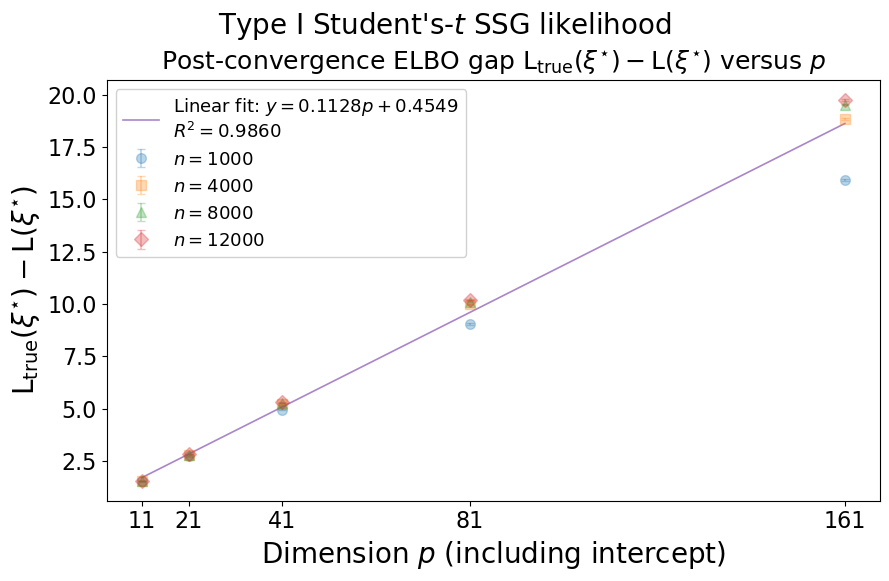

Saved figure: results_gaps/plots/gap_vs_p_linear_fit.pdf
Slope=0.112830; intercept=0.454860; R^2=0.985976


In [12]:
# Figure 5(a): ELBO gap versus p with linear regression fit
summary_df = summaries["elbo_gap"].copy()
plot_df = summary_df.sort_values("p").copy()

x = plot_df[["p"]].to_numpy()
y = plot_df["gap_mean"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["p"].min(), plot_df["p"].max(), 400).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(9, 6))
alpha_map = {1000: 0.30, 4000: 0.30, 8000: 0.30, 12000: 0.30}
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}

for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("p")
    plt.errorbar(
        sub["p"], sub["gap_mean"], yerr=sub["gap_se"],
        fmt=marker_map.get(n, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=alpha_map.get(n, 0.9), label=fr"$n={n}$"
    )

plt.plot(
    x_line, y_line, linewidth=1.2, alpha=0.8,
    label=(
        fr"Linear fit: $y = {slope:.4f}p + {intercept:.4f}$"
        "\n" fr"$R^2 = {r2:.4f}$"
    ),
)
plt.suptitle(r"Type I Student's-$t$ $\mathsf{SSG}$ likelihood", fontsize=20, y=0.96)
plt.title(
    r"Post-convergence ELBO gap $\mathsf{L}_{\mathrm{true}}(\xi^{\star})-\mathsf{L}(\xi^{\star})$ versus $p$",
    fontsize=18, pad=8,
)
plt.xlabel(r"Dimension $p$ (including intercept)", fontsize=20)
plt.ylabel(r"$\mathsf{L}_{\mathrm{true}}(\xi^{\star})-\mathsf{L}(\xi^{\star})$", fontsize=20)
plt.xticks(sorted(plot_df["p"].unique()), fontsize=18)
plt.tick_params(axis="both", labelsize=16)
plt.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=13)
plt.tight_layout()

fig_path = PLOTS_DIR / "gap_vs_p_linear_fit.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")

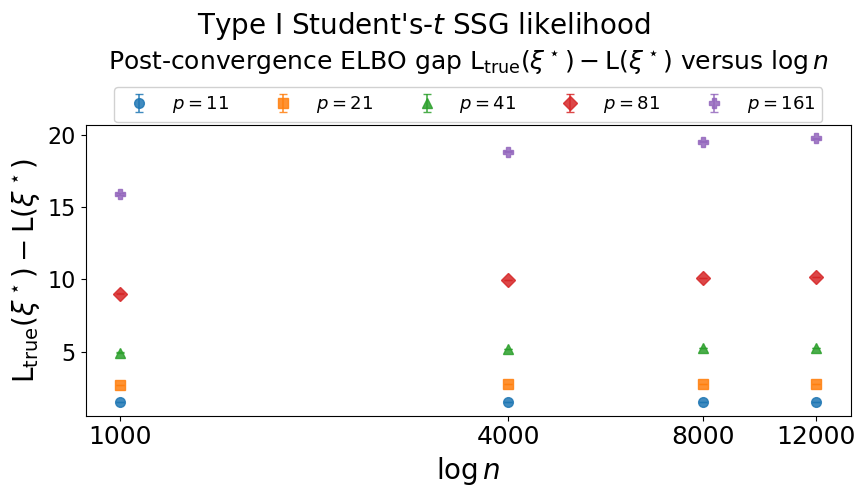

Saved figure: results_gaps/plots/gap_vs_log_n.pdf


In [13]:
# Figure 5(b): ELBO gap versus log n
summary_df = summaries["elbo_gap"].copy()
summary_df["log_n"] = np.log(summary_df["n"])

plt.figure(figsize=(9, 6))
marker_map = {11: "o", 21: "s", 41: "^", 81: "D", 161: "P"}

for p in sorted(summary_df["p"].unique()):
    sub = summary_df[summary_df["p"] == p].sort_values("n")
    plt.errorbar(
        sub["log_n"], sub["gap_mean"], yerr=sub["gap_se"],
        fmt=marker_map.get(p, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=0.85, label=fr"$p={p}$"
    )

plt.suptitle(r"Type I Student's-$t$ $\mathsf{SSG}$ likelihood", fontsize=20, y=0.82)
plt.title(
    r"Post-convergence ELBO gap $\mathsf{L}_{\mathrm{true}}(\xi^\star)-\mathsf{L}(\xi^\star)$ versus $\log n$",
    fontsize=18, pad=40,
)
plt.xlabel(r"$\log n$", fontsize=20)
plt.ylabel(r"$\mathsf{L}_{\mathrm{true}}(\xi^\star)-\mathsf{L}(\xi^\star)$", fontsize=20)
n_ticks = sorted(summary_df["n"].unique())
plt.xticks(np.log(n_ticks), [str(n) for n in n_ticks], fontsize=18)
plt.tick_params(axis="y", labelsize=16)
plt.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.16),
    ncol=len(sorted(summary_df["p"].unique())),
    frameon=True, fancybox=True, framealpha=0.9, fontsize=13,
)
plt.tight_layout(rect=[0, 0, 1, 0.86])

fig_path = PLOTS_DIR / "gap_vs_log_n.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

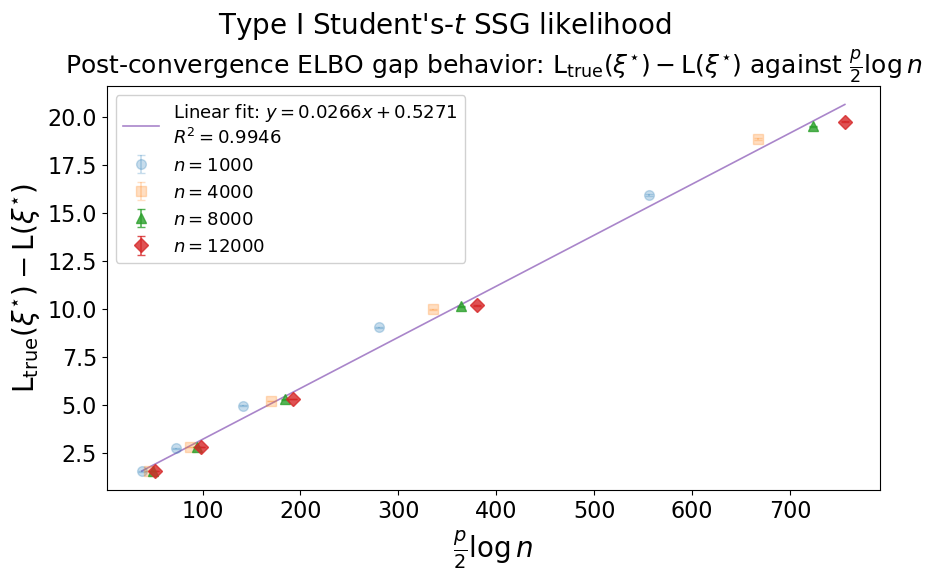

Saved figure: results_gaps/plots/gap_vs_half_p_log_n_linear_fit.pdf
Slope=0.026606; intercept=0.527097; R^2=0.994570


In [15]:
# Figure 5(c): ELBO gap versus (p/2) log n with linear fit
plot_df = summaries["elbo_gap"].sort_values("x_scaled").copy()
x = plot_df[["x_scaled"]].to_numpy()
y = plot_df["gap_mean"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["x_scaled"].min(), plot_df["x_scaled"].max(), 400).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(9, 6))
alpha_map = {1000: 0.25, 4000: 0.25, 8000: 0.80, 12000: 0.80}
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}

for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("x_scaled")
    plt.errorbar(
        sub["x_scaled"], sub["gap_mean"], yerr=sub["gap_se"],
        fmt=marker_map.get(n, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=alpha_map.get(n, 0.9), label=fr"$n={n}$"
    )

plt.plot(
    x_line, y_line, linewidth=1.2, alpha=0.8,
    label=(fr"Linear fit: $y = {slope:.4f}x + {intercept:.4f}$" "\n" fr"$R^2 = {r2:.4f}$"),
)
plt.xlabel(r"$\frac{p}{2}\log n$", fontsize=20)
plt.ylabel(r"$\mathsf{L}_{\mathrm{true}}(\xi^{\star})-\mathsf{L}(\xi^{\star})$", fontsize=20)
plt.suptitle(r"Type I Student's-$t$ $\mathsf{SSG}$ likelihood", fontsize=20, y=0.96)
plt.title(
    r"Post-convergence ELBO gap behavior: $\mathsf{L}_{\mathrm{true}}(\xi^{\star})-\mathsf{L}(\xi^{\star})$ against $\frac{p}{2}\log n$",
    fontsize=18, pad=8,
)
plt.tick_params(axis="both", labelsize=16)
plt.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=13)
plt.tight_layout()

fig_path = PLOTS_DIR / "gap_vs_half_p_log_n_linear_fit.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")

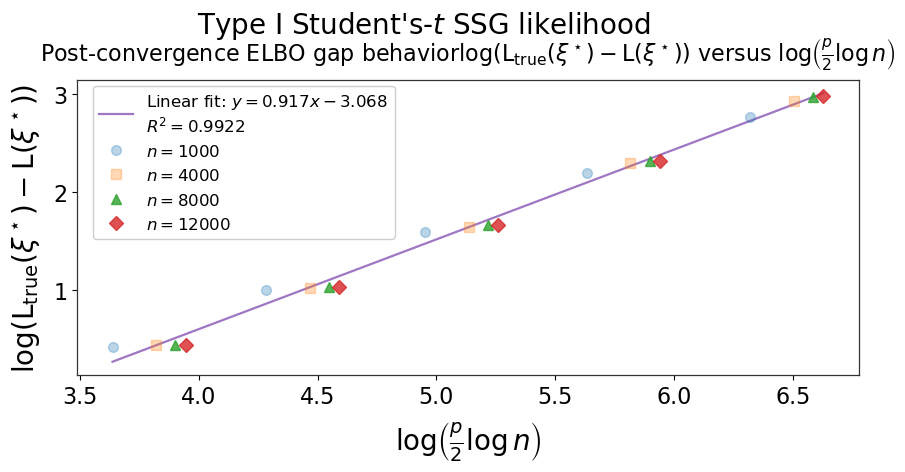

Saved figure: results_gaps/plots/log_gap_vs_log_half_p_log_n.pdf
Slope=0.917207; intercept=-3.068268; R^2=0.992232


In [19]:
# Figure 5(d): log ELBO gap versus log((p/2) log n)
summary_df = summaries["elbo_gap"].copy()
plot_df = summary_df.loc[
    (summary_df["gap_mean"] > 0) & (summary_df["x_scaled"] > 0)
].copy()
plot_df["log_x_scaled"] = np.log(plot_df["x_scaled"])
plot_df["log_gap"] = np.log(plot_df["gap_mean"])
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["log_x_scaled", "log_gap"]
)
if len(plot_df) < 2:
    raise ValueError("At least two positive finite observations are required.")

x = plot_df[["log_x_scaled"]].to_numpy()
y = plot_df["log_gap"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["log_x_scaled"].min(), plot_df["log_x_scaled"].max(), 400)
y_line = linreg.predict(x_line.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(9, 6), facecolor="white")
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}
alpha_map = {1000: 0.30, 4000: 0.30, 8000: 0.80, 12000: 0.80}

for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("log_x_scaled")
    ax.errorbar(
        sub["log_x_scaled"], sub["log_gap"],
        fmt=marker_map.get(n, "o"), markersize=7,
        alpha=alpha_map.get(n, 0.9), capsize=3,
        elinewidth=1.2, linewidth=1.0, label=fr"$n={n:g}$",
    )

ax.plot(
    x_line, y_line, linewidth=1.6, alpha=0.9,
    label=(fr"Linear fit: $y={slope:.3f}x{intercept:+.3f}$" "\n" fr"$R^2={r2:.4f}$"),
)
fig.suptitle(r"Type I Student's-$t$ $\mathsf{SSG}$ likelihood", fontsize=20, y=0.78)
ax.set_title(
    "Post-convergence ELBO gap behavior"
    r"$\log\!\left(\mathsf{L}_{\mathrm{true}}(\xi^\star)-\mathsf{L}(\xi^\star)\right)$ versus "
    r"$\log\!\left(\frac{p}{2}\log n\right)$",
    fontsize=16, pad=14,
)
ax.set_xlabel(r"$\log\!\left(\frac{p}{2}\log n\right)$", fontsize=20, labelpad=8)
ax.set_ylabel(
    r"$\log\!\left(\mathsf{L}_{\mathrm{true}}(\xi^\star)-\mathsf{L}(\xi^\star)\right)$",
    fontsize=20, labelpad=8,
)
ax.tick_params(axis="both", labelsize=16)
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(0.9)
ax.legend(
    loc="upper left", bbox_to_anchor=(0.02, 0.98), borderaxespad=0.0,
    frameon=True, fancybox=True, framealpha=0.95, fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.84])

fig_path = PLOTS_DIR / "log_gap_vs_log_half_p_log_n.pdf"
fig.savefig(fig_path, format="pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")

## Variational-gap plots (Figures 6 and 7)

These plots use the importance-sampling estimate collected from the same
TAVIE fit used above.

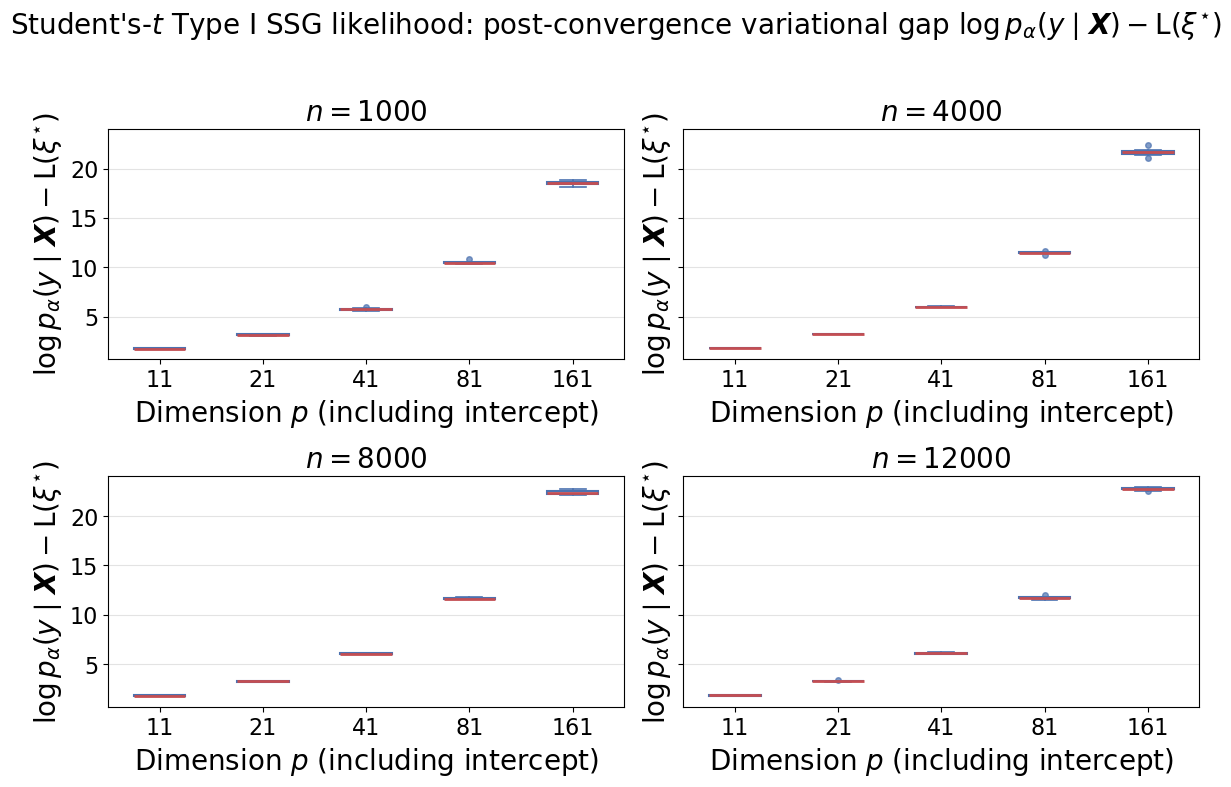

Saved figure: results_gaps/plots/student_t_logml_gap_boxplots.pdf


In [20]:
# Figure 6: boxplots of log p_alpha(y|X) - L(xi*)
n_values = sorted(raw_results["n"].unique())
p_values = sorted(raw_results["p"].unique())

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
})
color_box = "#dbe9f6"
color_median = "#c44e52"
color_edge = "#4c72b0"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()
for ax, n in zip(axes, n_values):
    data_for_n = [
        raw_results.loc[
            (raw_results["n"] == n) & (raw_results["p"] == p),
            "logml_gap_postconv",
        ].values
        for p in p_values
    ]
    ax.boxplot(
        data_for_n,
        tick_labels=[str(p) for p in p_values],
        patch_artist=True,
        medianprops=dict(color=color_median, linewidth=2.0),
        boxprops=dict(facecolor=color_box, edgecolor=color_edge, linewidth=1.5),
        whiskerprops=dict(color=color_edge, linewidth=1.2),
        capprops=dict(color=color_edge, linewidth=1.2),
        flierprops=dict(
            marker="o", markerfacecolor=color_edge, markeredgecolor=color_edge,
            markersize=4, alpha=0.7,
        ),
    )
    ax.set_title(fr"$n={n}$", fontsize=20)
    ax.set_xlabel(r"Dimension $p$ (including intercept)", fontsize=20)
    ax.set_ylabel(
        r"$\log p_{\alpha}(y\mid \boldsymbol{X})-\mathsf{L}(\xi^{\star})$",
        fontsize=20,
    )
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(axis="y", alpha=0.35)

fig.suptitle(
    r"Student's-$t$ Type I $\mathsf{SSG}$ likelihood: post-convergence variational gap "
    r"$\log p_{\alpha}(y\mid \boldsymbol{X})-\mathsf{L}(\xi^{\star})$",
    fontsize=20, y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig_path = PLOTS_DIR / "student_t_logml_gap_boxplots.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

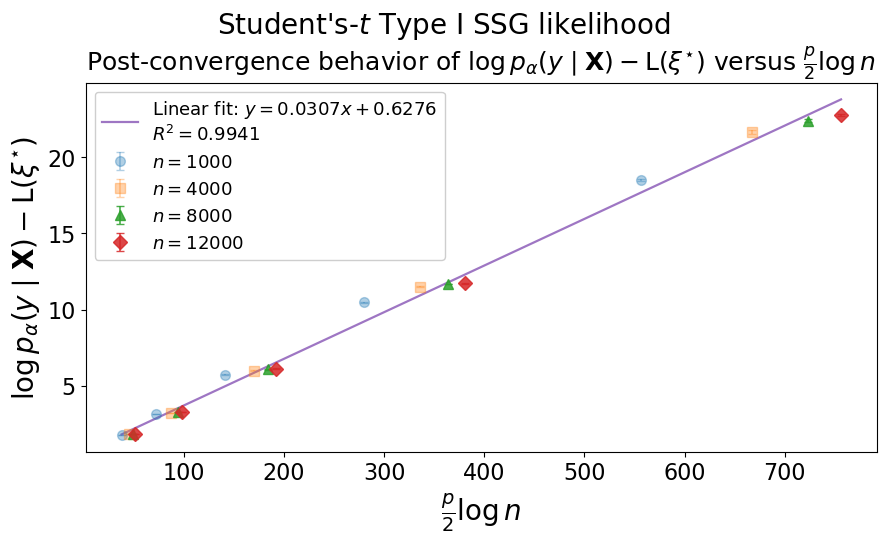

Saved figure: results_gaps/plots/student_t_logml_gap_vs_half_p_log_n_linear_fit.pdf
Slope=0.030655; intercept=0.627622; R^2=0.994109


In [22]:
# Figure 7(a): variational gap versus (p/2) log n with linear fit
plot_df = summaries["logml_gap"].sort_values("x_scaled").copy()
x = plot_df[["x_scaled"]].to_numpy()
y = plot_df["gap_mean"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["x_scaled"].min(), plot_df["x_scaled"].max(), 400).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(9, 6))
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}
alpha_map = {1000: 0.35, 4000: 0.35, 8000: 0.85, 12000: 0.85}
for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("x_scaled")
    plt.errorbar(
        sub["x_scaled"], sub["gap_mean"], yerr=sub["gap_se"],
        fmt=marker_map.get(n, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=alpha_map.get(n, 0.9), label=fr"$n={n}$",
    )
plt.plot(
    x_line, y_line, linewidth=1.6, alpha=0.9,
    label=(fr"Linear fit: $y={slope:.4f}x+{intercept:.4f}$" "\n" fr"$R^2={r2:.4f}$"),
)
plt.suptitle(r"Student's-$t$ Type I $\mathsf{SSG}$ likelihood", fontsize=20, y=0.90)
plt.title(
    r"Post-convergence behavior of $\log p_{\alpha}(y\mid \mathbf{X})-\mathsf{L}(\xi^{\star})$ versus $\frac{p}{2}\log n$",
    fontsize=18, pad=8,
)
plt.xlabel(r"$\frac{p}{2}\log n$", fontsize=20)
plt.ylabel(r"$\log p_{\alpha}(y\mid \mathbf{X})-\mathsf{L}(\xi^{\star})$", fontsize=20)
plt.tick_params(axis="both", labelsize=16)
plt.legend(loc="upper left", frameon=True, fancybox=True, framealpha=0.95, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig_path = PLOTS_DIR / "student_t_logml_gap_vs_half_p_log_n_linear_fit.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")

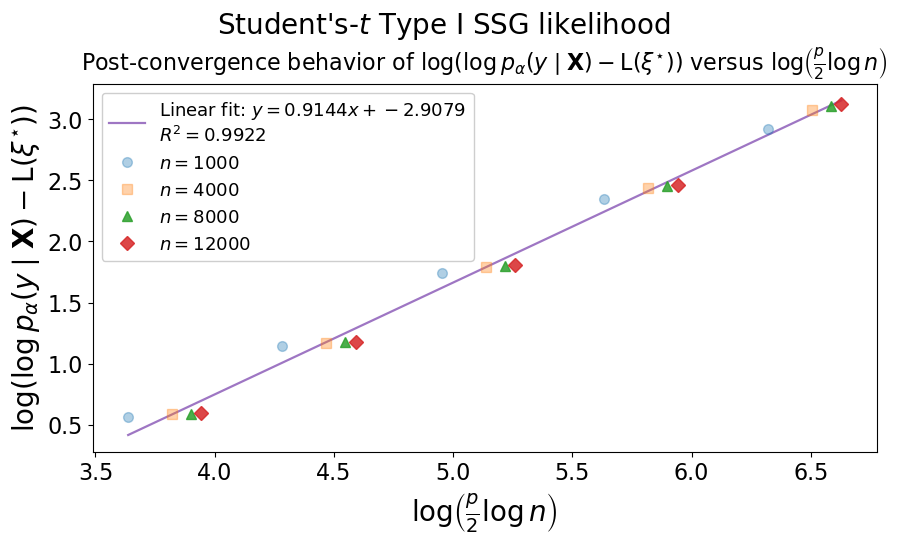

Saved figure: results_gaps/plots/student_t_log_gap_vs_log_half_p_log_n_linear_fit.pdf
Slope=0.914398; intercept=-2.907928; R^2=0.992236


In [24]:
# Figure 7(b): log variational gap versus log((p/2) log n)
summary_df = summaries["logml_gap"].copy()
plot_df = summary_df.loc[
    (summary_df["gap_mean"] > 0) & (summary_df["x_scaled"] > 0)
].copy()
plot_df["log_x_scaled"] = np.log(plot_df["x_scaled"])
plot_df["log_gap"] = np.log(plot_df["gap_mean"])
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["log_x_scaled", "log_gap"]
).sort_values("log_x_scaled")
if len(plot_df) < 2:
    raise ValueError("At least two positive finite observations are required.")

x = plot_df[["log_x_scaled"]].to_numpy()
y = plot_df["log_gap"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["log_x_scaled"].min(), plot_df["log_x_scaled"].max(), 400).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(9, 6))
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}
alpha_map = {1000: 0.35, 4000: 0.35, 8000: 0.85, 12000: 0.85}
for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("log_x_scaled")
    plt.errorbar(
        sub["log_x_scaled"], sub["log_gap"],
        fmt=marker_map.get(n, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=alpha_map.get(n, 0.9), label=fr"$n={n}$",
    )
plt.plot(
    x_line, y_line, linewidth=1.6, alpha=0.9,
    label=(fr"Linear fit: $y={slope:.4f}x+{intercept:.4f}$" "\n" fr"$R^2={r2:.4f}$"),
)
plt.suptitle(r"Student's-$t$ Type I $\mathsf{SSG}$ likelihood", fontsize=20, y=0.90)
plt.title(
    r"Post-convergence behavior of $\log\!\left(\log p_{\alpha}(y\mid \mathbf{X})-\mathsf{L}(\xi^{\star})\right)$ versus "
    r"$\log\!\left(\frac{p}{2}\log n\right)$",
    fontsize=16, pad=10,
)
plt.xlabel(r"$\log\!\left(\frac{p}{2}\log n\right)$", fontsize=20)
plt.ylabel(
    r"$\log\!\left(\log p_{\alpha}(y\mid \mathbf{X})-\mathsf{L}(\xi^{\star})\right)$",
    fontsize=20,
)
plt.tick_params(axis="both", labelsize=16)
plt.legend(loc="upper left", frameon=True, fancybox=True, framealpha=0.95, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig_path = PLOTS_DIR / "student_t_log_gap_vs_log_half_p_log_n_linear_fit.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")

## ELBO minus the true-parameter log likelihood (Figure 8)

This final plot also uses the intercept-inclusive $p$ in
$(p/2)\log n$.

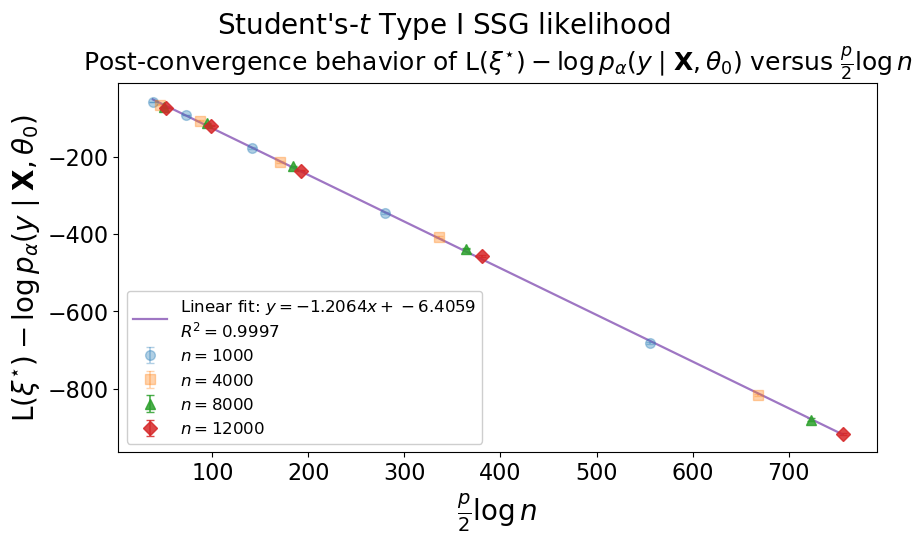

Saved figure: results_gaps/plots/student_t_elbo_minus_true_loglik_vs_half_p_log_n_linear_fit.pdf
Slope=-1.206373; intercept=-6.405921; R^2=0.999721


In [25]:
# Figure 8: L(xi*) - log p_alpha(y|X,theta0) versus (p/2) log n
plot_df = summaries["elbo_minus_true_loglik"].sort_values("x_scaled").copy()
x = plot_df[["x_scaled"]].to_numpy()
y = plot_df["gap_mean"].to_numpy()
linreg = LinearRegression().fit(x, y)
y_fit = linreg.predict(x)
r2 = r2_score(y, y_fit)
slope = float(linreg.coef_[0])
intercept = float(linreg.intercept_)
x_line = np.linspace(plot_df["x_scaled"].min(), plot_df["x_scaled"].max(), 400).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(9, 6))
marker_map = {1000: "o", 4000: "s", 8000: "^", 12000: "D"}
alpha_map = {1000: 0.35, 4000: 0.35, 8000: 0.85, 12000: 0.85}
for n in sorted(plot_df["n"].unique()):
    sub = plot_df[plot_df["n"] == n].sort_values("x_scaled")
    plt.errorbar(
        sub["x_scaled"], sub["gap_mean"], yerr=sub["gap_se"],
        fmt=marker_map.get(n, "o"), markersize=7, capsize=3,
        elinewidth=1.2, alpha=alpha_map.get(n, 0.9), label=fr"$n={n}$",
    )
plt.plot(
    x_line, y_line, linewidth=1.6, alpha=0.9,
    label=(fr"Linear fit: $y={slope:.4f}x+{intercept:.4f}$" "\n" fr"$R^2={r2:.4f}$"),
)
plt.suptitle(r"Student's-$t$ Type I $\mathsf{SSG}$ likelihood", fontsize=20, y=0.90)
plt.title(
    r"Post-convergence behavior of $\mathsf{L}(\xi^{\star})-\log p_{\alpha}(y\mid \mathbf{X},\theta_0)$ versus $\frac{p}{2}\log n$",
    fontsize=18, pad=8,
)
plt.xlabel(r"$\frac{p}{2}\log n$", fontsize=20)
plt.ylabel(
    r"$\mathsf{L}(\xi^{\star})-\log p_{\alpha}(y\mid \mathbf{X},\theta_0)$",
    fontsize=20,
)
plt.tick_params(axis="both", labelsize=16)
plt.legend(loc="lower left", frameon=True, fancybox=True, framealpha=0.95, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig_path = PLOTS_DIR / "student_t_elbo_minus_true_loglik_vs_half_p_log_n_linear_fit.pdf"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
print(f"Slope={slope:.6f}; intercept={intercept:.6f}; R^2={r2:.6f}")